# Health Insurance Fraud Detection — Final Model Evaluation

## Objective

This notebook performs the **final out-of-time evaluation** of the model selected in `04_model_experiments.ipynb`.

The model-selection stage is now closed.

### Frozen champion

The selected model is:

**XGBoost — raw probabilities**

Frozen hyperparameters:

- `n_estimators = 350`
- `learning_rate = 0.04`
- `max_depth = 3`
- `min_child_weight = 4`
- `subsample = 0.85`
- `colsample_bytree = 0.85`
- `reg_alpha = 0.0`
- `reg_lambda = 2.0`
- `scale_pos_weight = 1.0`
- `tree_method = "hist"`

### Frozen operating policy

The primary business policy is:

> **Review the top 3% highest-risk claims.**

This is preferable to choosing a new probability threshold after seeing the test set.

### Test-set governance

The 2026 test period is opened **once** in this notebook.

No hyperparameter tuning, feature selection, calibration fitting or threshold optimization is permitted after viewing test performance.

The purpose of the test set is estimation, not model development.

## 1. Imports and project setup

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "interim"

MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
PREPROCESSOR_DIR = PROJECT_ROOT / "artifacts" / "preprocessors"
METADATA_DIR = PROJECT_ROOT / "artifacts" / "metadata"
FIGURES_DIR = METADATA_DIR / "final_evaluation"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSOR_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

claims = pd.read_parquet(DATA_DIR / "claims.parquet")

print(f"Claims: {len(claims):,}")
print(f"Columns: {claims.shape[1]}")
print(f"Overall fraud prevalence: {claims['is_fraud'].mean():.3%}")

Claims: 99,911
Columns: 55
Overall fraud prevalence: 2.504%


## 2. Reproduce the frozen feature contract

In [2]:
TARGET = "is_fraud"

IDENTIFIER_COLUMNS = [
    "claim_id",
    "customer_id",
    "policy_id",
    "provider_id",
]

LEAKAGE_COLUMNS = [
    "legitimate_anomaly",
    "legitimate_anomaly_type",
    "latent_fraud_score",
    "synthetic_fraud_probability",
    "fraud_difficulty",
    "fraud_mechanism",
]

SYNTHETIC_PROFILE_COLUMNS = [
    "customer_behavior_segment",
    "provider_behavior_segment",
]

RAW_DATE_COLUMNS = [
    "service_date",
    "claim_submission_date",
    "claim_submission_timestamp",
]

# Missingness indicators
claims["has_prescription_missing"] = (
    claims["has_prescription"].isna().astype("int8")
)

claims["document_count_missing"] = (
    claims["document_count"].isna().astype("int8")
)

claims["provider_missing"] = (
    claims["provider_id"].isna().astype("int8")
)

# Calendar features
claims["submission_hour"] = (
    claims["claim_submission_timestamp"].dt.hour
)

claims["submission_dayofweek"] = (
    claims["claim_submission_timestamp"].dt.dayofweek
)

claims["submission_month"] = (
    claims["claim_submission_timestamp"].dt.month
)

claims["submission_is_weekend"] = (
    claims["submission_dayofweek"] >= 5
).astype("int8")

claims["service_dayofweek"] = (
    claims["service_date"].dt.dayofweek
)

claims["service_month"] = (
    claims["service_date"].dt.month
)

claims["service_is_weekend"] = (
    claims["service_dayofweek"] >= 5
).astype("int8")

# Contextual business features
EPS = 1e-6

claims["requested_to_limit_ratio"] = (
    claims["requested_reimbursement"]
    / claims["coverage_limit"].clip(lower=EPS)
)

claims["amount_above_service_typical"] = (
    claims["claim_amount"]
    - claims["service_typical_amount"]
)

claims["recent_claim_share_30d_365d"] = (
    claims["customer_claims_30d"]
    / claims["customer_claims_365d"].replace(0, np.nan)
)

claims["recent_amount_share_30d_365d"] = (
    claims["customer_amount_30d"]
    / claims["customer_amount_365d"].replace(0, np.nan)
)

claims["provider_recent_activity_ratio"] = (
    (claims["provider_claims_30d"] + 1)
    / (claims["provider_claims_90d"] / 3 + 1)
)

claims["customer_provider_intensity"] = (
    claims["customer_provider_claims_30d"]
    / (claims["customer_claims_30d"] + 1)
)

claims["same_service_intensity"] = (
    claims["same_service_claims_30d"]
    / (claims["customer_claims_30d"] + 1)
)

claims["days_since_policy_change_missing"] = (
    claims["days_since_policy_change"].isna().astype("int8")
)

MODEL_EXCLUSIONS = (
    IDENTIFIER_COLUMNS
    + LEAKAGE_COLUMNS
    + SYNTHETIC_PROFILE_COLUMNS
    + RAW_DATE_COLUMNS
    + [TARGET]
)

FEATURES = [
    column
    for column in claims.columns
    if column not in MODEL_EXCLUSIONS
]

assert not set(LEAKAGE_COLUMNS).intersection(FEATURES)
assert not set(IDENTIFIER_COLUMNS).intersection(FEATURES)

print(f"Frozen model features: {len(FEATURES)}")
print("Leakage audit: PASS")

Frozen model features: 57
Leakage audit: PASS


The feature definition is intentionally identical to notebook 04.

No additional feature is introduced after model selection.

## 3. Final train / test split

In [3]:
PRETEST_END = pd.Timestamp("2025-12-31 23:59:59")

pretest = claims.loc[
    claims["claim_submission_timestamp"] <= PRETEST_END
].copy()

test = claims.loc[
    claims["claim_submission_timestamp"] > PRETEST_END
].copy()

split_summary = pd.DataFrame(
    [
        {
            "split": "final_training_pretest",
            "rows": len(pretest),
            "fraud_cases": int(pretest[TARGET].sum()),
            "fraud_rate_pct": pretest[TARGET].mean() * 100,
            "first_claim": pretest["claim_submission_timestamp"].min(),
            "last_claim": pretest["claim_submission_timestamp"].max(),
        },
        {
            "split": "final_test_2026",
            "rows": len(test),
            "fraud_cases": int(test[TARGET].sum()),
            "fraud_rate_pct": test[TARGET].mean() * 100,
            "first_claim": test["claim_submission_timestamp"].min(),
            "last_claim": test["claim_submission_timestamp"].max(),
        },
    ]
)

split_summary

,split,rows,fraud_cases,fraud_rate_pct,first_claim,last_claim
0,final_training_pretest,85735,2093,2.4412,2023-01-01 00:22:09,2025-12-31 23:34:55
1,final_test_2026,14176,409,2.8852,2026-01-01 00:17:34,2026-06-30 23:59:59


All observations through **31 December 2025** are now used to fit the frozen champion.

This is allowed because model selection has already been completed.

The 2026 observations remain untouched until prediction below.

## 4. Build frozen preprocessing pipeline

In [4]:
BOOLEAN_FEATURES = [
    column
    for column in FEATURES
    if (
        pd.api.types.is_bool_dtype(claims[column])
        or column.endswith("_missing")
        or column.endswith("_is_weekend")
        or column == "provider_missing"
    )
]

CATEGORICAL_FEATURES = [
    column
    for column in FEATURES
    if pd.api.types.is_object_dtype(claims[column])
]

NUMERIC_FEATURES = [
    column
    for column in FEATURES
    if (
        pd.api.types.is_numeric_dtype(claims[column])
        and column not in BOOLEAN_FEATURES
    )
]

numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="__MISSING__",
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=10,
            ),
        ),
    ]
)

boolean_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES,
        ),
        (
            "boolean",
            boolean_pipeline,
            BOOLEAN_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train = pretest[FEATURES]
y_train = pretest[TARGET].astype(int)

X_test = test[FEATURES]
y_test = test[TARGET].astype(int)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print(f"Final training matrix: {X_train_t.shape}")
print(f"Final test matrix:     {X_test_t.shape}")

Final training matrix: (85735, 107)
Final test matrix:     (14176, 107)


## 5. Fit the frozen XGBoost champion

In [5]:
FINAL_XGB_PARAMS = {
    "objective": "binary:logistic",
    "n_estimators": 350,
    "learning_rate": 0.04,
    "max_depth": 3,
    "min_child_weight": 4,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.0,
    "reg_lambda": 2.0,
    "scale_pos_weight": 1.0,
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "n_jobs": -1,
    "random_state": RANDOM_SEED,
}

final_model = XGBClassifier(
    **FINAL_XGB_PARAMS
)

final_model.fit(
    X_train_t,
    y_train,
)

print("Frozen champion fitted successfully.")

Frozen champion fitted successfully.


## 6. Open the held-out 2026 test set

In [6]:
test_probabilities = (
    final_model
    .predict_proba(X_test_t)[:, 1]
)

print("2026 test set scored.")
print(f"Predictions: {len(test_probabilities):,}")
print(
    f"Mean predicted risk: "
    f"{test_probabilities.mean():.3%}"
)

2026 test set scored.
Predictions: 14,176
Mean predicted risk: 2.771%


From this point onward, test results may be analyzed and reported, but **the model configuration must not be changed** based on those results.

## 7. Final discrimination and probability metrics

In [7]:
FINAL_AP = average_precision_score(
    y_test,
    test_probabilities,
)

FINAL_ROC_AUC = roc_auc_score(
    y_test,
    test_probabilities,
)

FINAL_BRIER = brier_score_loss(
    y_test,
    test_probabilities,
)

FINAL_LOG_LOSS = log_loss(
    y_test,
    test_probabilities,
    labels=[0, 1],
)

final_statistical_metrics = pd.Series(
    {
        "test_rows": len(test),
        "fraud_cases": int(y_test.sum()),
        "fraud_prevalence": y_test.mean(),
        "average_precision": FINAL_AP,
        "roc_auc": FINAL_ROC_AUC,
        "brier_score": FINAL_BRIER,
        "log_loss": FINAL_LOG_LOSS,
    }
)

final_statistical_metrics

test_rows           14,176.0000
fraud_cases            409.0000
fraud_prevalence         0.0289
average_precision        0.5520
roc_auc                  0.8518
brier_score              0.0174
log_loss                 0.0797
dtype: float64

## 8. Primary business policy — top 3% review capacity

In [8]:
REVIEW_FRACTION = 0.03

n_review = max(
    1,
    int(
        np.ceil(
            len(test)
            * REVIEW_FRACTION
        )
    ),
)

ranking = np.argsort(
    -test_probabilities
)

reviewed_indices = ranking[
    :n_review
]

top3_prediction = np.zeros(
    len(test),
    dtype=int,
)

top3_prediction[
    reviewed_indices
] = 1

reviewed_y = (
    y_test
    .to_numpy()[
        reviewed_indices
    ]
)

precision_at_3 = (
    reviewed_y.mean()
)

recall_at_3 = (
    reviewed_y.sum()
    / max(y_test.sum(), 1)
)

lift_at_3 = (
    precision_at_3
    / y_test.mean()
)

test_amounts = (
    test[
        "claim_amount"
    ]
    .to_numpy()
)

total_fraud_amount = (
    test_amounts[
        y_test.to_numpy() == 1
    ]
    .sum()
)

captured_fraud_amount = (
    test_amounts[
        reviewed_indices
    ][
        reviewed_y == 1
    ]
    .sum()
)

fraud_amount_capture_at_3 = (
    captured_fraud_amount
    / total_fraud_amount
)

business_metrics_3pct = pd.Series(
    {
        "review_fraction": REVIEW_FRACTION,
        "claims_reviewed": n_review,
        "precision_at_3pct": precision_at_3,
        "recall_at_3pct": recall_at_3,
        "lift_at_3pct": lift_at_3,
        "fraud_amount_capture_at_3pct": fraud_amount_capture_at_3,
    }
)

business_metrics_3pct

review_fraction                  0.0300
claims_reviewed                426.0000
precision_at_3pct                0.5164
recall_at_3pct                   0.5379
lift_at_3pct                    17.8996
fraud_amount_capture_at_3pct     0.5515
dtype: float64

## 9. Final confusion matrix at the 3% operating policy

In [9]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    top3_prediction,
).ravel()

confusion_summary = pd.Series(
    {
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "precision": precision_score(
            y_test,
            top3_prediction,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            top3_prediction,
            zero_division=0,
        ),
    }
)

confusion_summary

true_negatives    13,561.0000
false_positives      206.0000
false_negatives      189.0000
true_positives       220.0000
precision              0.5164
recall                 0.5379
dtype: float64

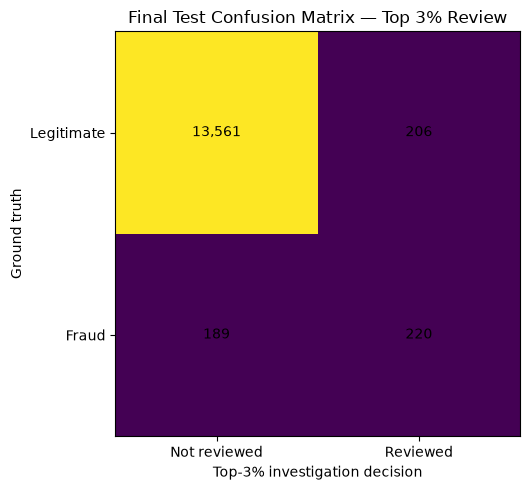

In [10]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

matrix = np.array(
    [
        [tn, fp],
        [fn, tp],
    ]
)

image = ax.imshow(matrix)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{matrix[i, j]:,}",
            ha="center",
            va="center",
        )

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Not reviewed", "Reviewed"]
)

ax.set_yticks([0, 1])
ax.set_yticklabels(
    ["Legitimate", "Fraud"]
)

ax.set_xlabel(
    "Top-3% investigation decision"
)

ax.set_ylabel(
    "Ground truth"
)

ax.set_title(
    "Final Test Confusion Matrix — Top 3% Review"
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "01_confusion_matrix_top3.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

## 10. Precision–Recall curve

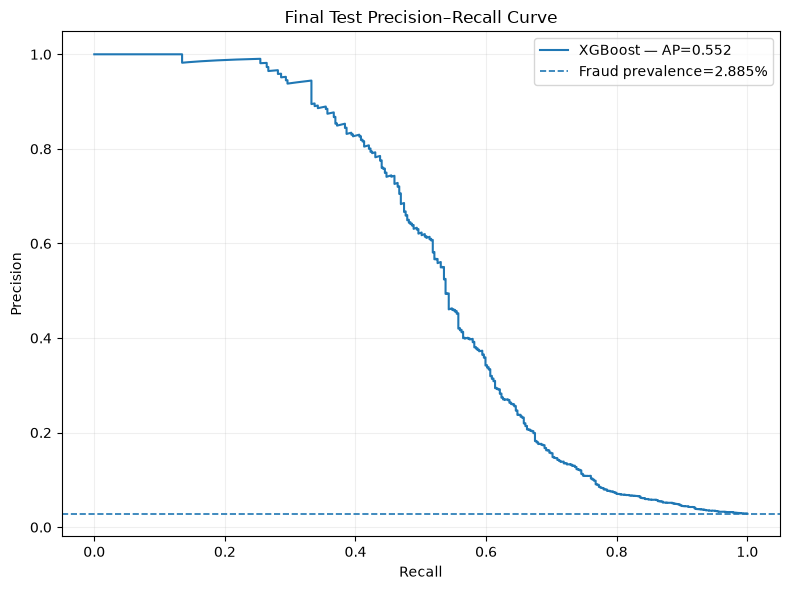

In [11]:
precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_probabilities,
    )
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    recall_curve,
    precision_curve,
    label=(
        f"XGBoost — "
        f"AP={FINAL_AP:.3f}"
    ),
)

ax.axhline(
    y_test.mean(),
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Fraud prevalence="
        f"{y_test.mean():.3%}"
    ),
)

ax.set_title(
    "Final Test Precision–Recall Curve"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "02_precision_recall_test.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

## 11. ROC curve

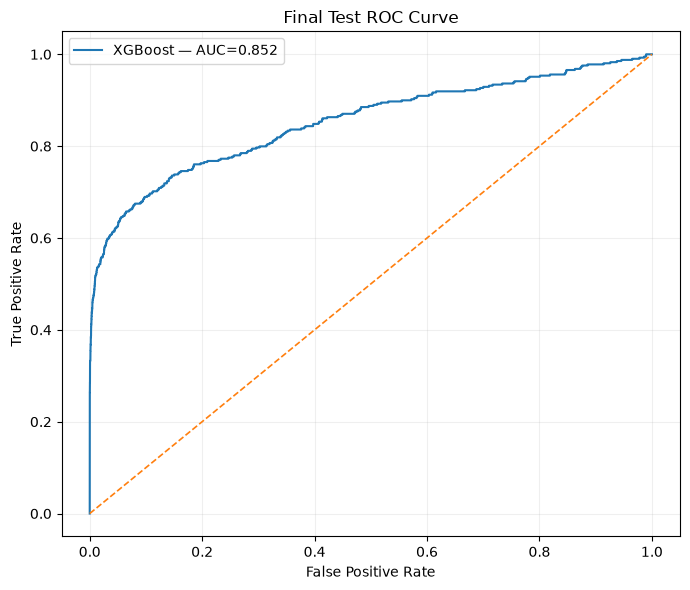

In [12]:
fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities,
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    fpr,
    tpr,
    label=(
        f"XGBoost — "
        f"AUC={FINAL_ROC_AUC:.3f}"
    ),
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
)

ax.set_title(
    "Final Test ROC Curve"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_roc_test.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

## 12. Probability calibration

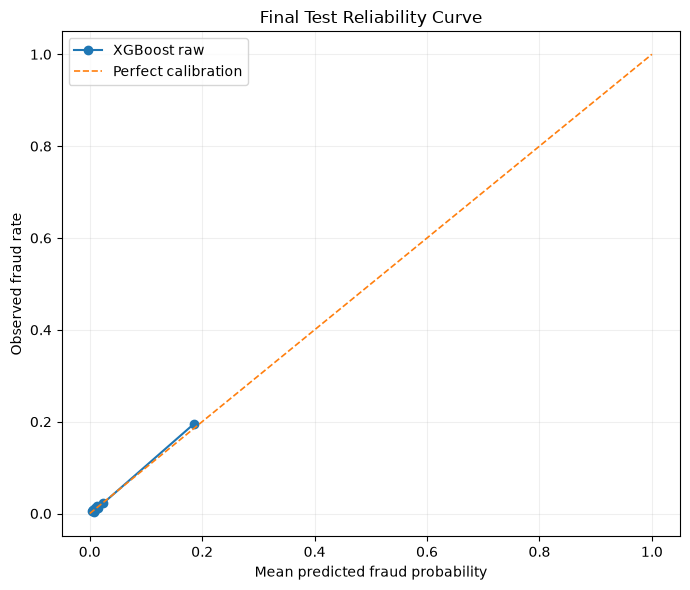

In [13]:
prob_true, prob_pred = (
    calibration_curve(
        y_test,
        test_probabilities,
        n_bins=10,
        strategy="quantile",
    )
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost raw",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Perfect calibration",
)

ax.set_title(
    "Final Test Reliability Curve"
)

ax.set_xlabel(
    "Mean predicted fraud probability"
)

ax.set_ylabel(
    "Observed fraud rate"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "04_calibration_test.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

## 13. Investigation capacity curve

In [14]:
def capacity_metrics(
    fraction,
):
    k = max(
        1,
        int(
            np.ceil(
                len(test)
                * fraction
            )
        ),
    )

    selected = ranking[:k]

    selected_y = (
        y_test
        .to_numpy()[
            selected
        ]
    )

    precision_k = (
        selected_y.mean()
    )

    recall_k = (
        selected_y.sum()
        / y_test.sum()
    )

    lift_k = (
        precision_k
        / y_test.mean()
    )

    selected_amount = (
        test_amounts[
            selected
        ][
            selected_y == 1
        ]
        .sum()
    )

    amount_capture_k = (
        selected_amount
        / total_fraud_amount
    )

    return {
        "review_fraction": fraction,
        "claims_reviewed": k,
        "precision": precision_k,
        "recall": recall_k,
        "lift": lift_k,
        "fraud_amount_capture": amount_capture_k,
    }


capacity_results = pd.DataFrame(
    [
        capacity_metrics(fraction)
        for fraction in [
            0.005,
            0.01,
            0.02,
            0.03,
            0.05,
            0.075,
            0.10,
            0.15,
        ]
    ]
)

capacity_results

,review_fraction,claims_reviewed,precision,recall,lift,fraud_amount_capture
0,0.0050,71,0.9859,0.1711,34.1720,0.1693
1,0.0100,142,0.9437,0.3276,32.7075,0.3283
2,0.0200,284,0.6831,0.4743,23.6763,0.4866
3,0.0300,426,0.5164,0.5379,17.8996,0.5515
4,0.0500,709,0.3456,0.5990,11.9771,0.6080
5,0.0750,1064,0.2481,0.6455,8.5999,0.6874
6,0.1000,1418,0.1946,0.6748,6.7463,0.7244
7,0.1500,2127,0.1382,0.7188,4.7908,0.7669


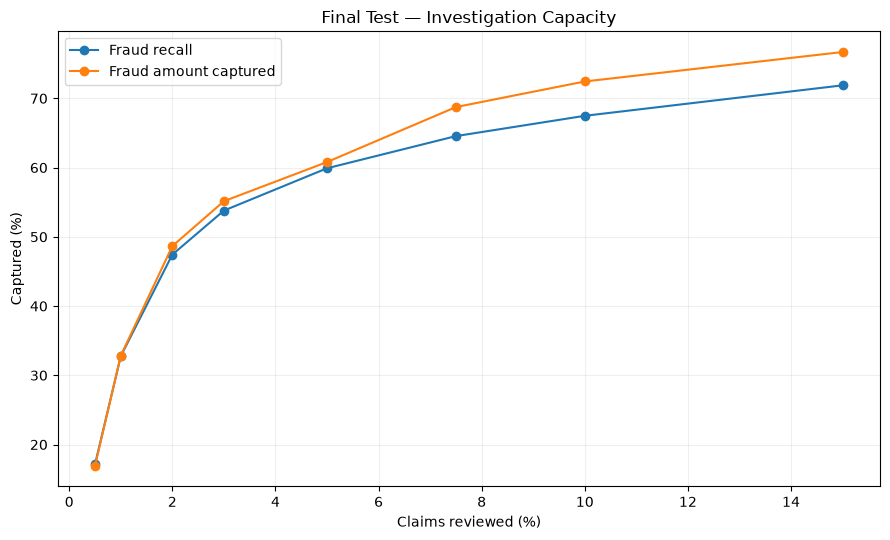

In [15]:
fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.plot(
    capacity_results[
        "review_fraction"
    ] * 100,
    capacity_results[
        "recall"
    ] * 100,
    marker="o",
    label="Fraud recall",
)

ax.plot(
    capacity_results[
        "review_fraction"
    ] * 100,
    capacity_results[
        "fraud_amount_capture"
    ] * 100,
    marker="o",
    label="Fraud amount captured",
)

ax.set_title(
    "Final Test — Investigation Capacity"
)

ax.set_xlabel(
    "Claims reviewed (%)"
)

ax.set_ylabel(
    "Captured (%)"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "05_capacity_curve.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

## 14. Risk concentration by score decile

In [16]:
test_scored = test[
    [
        "claim_id",
        "claim_amount",
        TARGET,
        "fraud_mechanism",
        "fraud_difficulty",
        "legitimate_anomaly",
        "legitimate_anomaly_type",
    ]
].copy()

test_scored[
    "fraud_risk_score"
] = test_probabilities

test_scored[
    "risk_decile"
] = pd.qcut(
    test_scored[
        "fraud_risk_score"
    ],
    q=10,
    labels=False,
    duplicates="drop",
)

test_scored[
    "risk_decile"
] = (
    10
    - test_scored[
        "risk_decile"
    ]
)

decile_summary = (
    test_scored
    .groupby(
        "risk_decile"
    )
    .agg(
        claims=(
            "claim_id",
            "size",
        ),
        fraud_cases=(
            TARGET,
            "sum",
        ),
        fraud_rate=(
            TARGET,
            "mean",
        ),
        mean_score=(
            "fraud_risk_score",
            "mean",
        ),
        total_claim_amount=(
            "claim_amount",
            "sum",
        ),
    )
    .sort_index()
)

decile_summary

,claims,fraud_cases,fraud_rate,mean_score,total_claim_amount
risk_decile,,,,,
1,1418,276,0.1946,0.1848,"477,193.6000"
2,1417,31,0.0219,0.0234,"393,030.5300"
3,1418,16,0.0113,0.0154,"333,465.0500"
4,1417,22,0.0155,0.0121,"302,465.2900"
5,1418,17,0.0120,0.0100,"294,024.2800"
6,1417,10,0.0071,0.0086,"268,695.8400"
7,1418,6,0.0042,0.0074,"247,167.3500"
8,1417,11,0.0078,0.0063,"239,704.0000"
9,1418,11,0.0078,0.0053,"225,022.3800"


A useful fraud model should concentrate substantially more fraud in the highest-risk deciles than in the overall portfolio.

## 15. Fraud mechanism performance

For mechanism-level recall, use row-position alignment explicitly rather than relying on original DataFrame indices.

In [17]:
test_scored = test_scored.reset_index(drop=True)

assert len(test_scored) == len(top3_prediction), (
    "Length mismatch between scored test rows and top-3% decisions."
)

test_scored["reviewed_top3"] = top3_prediction.astype(bool)

mechanism_performance = (
    test_scored.loc[
        test_scored[TARGET] == 1
    ]
    .groupby("fraud_mechanism")
    .agg(
        fraud_claims=(TARGET, "size"),
        mean_score=("fraud_risk_score", "mean"),
        median_score=("fraud_risk_score", "median"),
        recall_at_3pct=("reviewed_top3", "mean"),
        fraud_amount=("claim_amount", "sum"),
    )
    .sort_values(
        "recall_at_3pct",
        ascending=False,
    )
)

mechanism_performance


,fraud_claims,mean_score,median_score,recall_at_3pct,fraud_amount
fraud_mechanism,,,,,
customer_provider_pattern,66,0.7863,0.9770,0.8030,"13,907.9700"
repeated_service,58,0.4874,0.4352,0.6897,"12,784.8500"
mixed_pattern,68,0.5136,0.5448,0.6176,"17,653.8600"
frequency_abuse,71,0.3084,0.2292,0.5775,"18,801.4700"
provider_abnormality,71,0.2693,0.1772,0.5352,"16,999.5800"
amount_inflation,75,0.0372,0.0200,0.0800,"26,636.6200"


## 16. Difficulty-level performance

In [18]:
difficulty_performance = (
    test_scored.loc[
        test_scored[TARGET] == 1
    ]
    .groupby(
        "fraud_difficulty"
    )
    .agg(
        fraud_claims=(
            TARGET,
            "size",
        ),
        mean_score=(
            "fraud_risk_score",
            "mean",
        ),
        median_score=(
            "fraud_risk_score",
            "median",
        ),
        recall_at_3pct=(
            "reviewed_top3",
            "mean",
        ),
    )
    .sort_values(
        "recall_at_3pct",
        ascending=False,
    )
)

difficulty_performance

,fraud_claims,mean_score,median_score,recall_at_3pct
fraud_difficulty,,,,
easy,113,0.5577,0.6707,0.6726
medium,220,0.3811,0.2050,0.5545
hard,76,0.1583,0.0261,0.2895


## 17. False-positive analysis

In [19]:
false_positives = (
    test_scored.loc[
        (test_scored[TARGET] == 0)
        & (
            test_scored[
                "reviewed_top3"
            ]
        )
    ]
    .copy()
)

false_positive_summary = pd.Series(
    {
        "false_positive_claims": len(false_positives),
        "share_legitimate_anomalies": (
            false_positives[
                "legitimate_anomaly"
            ].mean()
        ),
        "median_risk_score": (
            false_positives[
                "fraud_risk_score"
            ].median()
        ),
        "median_claim_amount": (
            false_positives[
                "claim_amount"
            ].median()
        ),
    }
)

false_positive_summary

false_positive_claims        206.0000
share_legitimate_anomalies     0.5777
median_risk_score              0.2090
median_claim_amount          212.3700
dtype: float64

In [20]:
false_positive_types = (
    false_positives[
        "legitimate_anomaly_type"
    ]
    .value_counts(
        dropna=False,
    )
    .to_frame(
        "false_positive_claims"
    )
)

false_positive_types

,false_positive_claims
legitimate_anomaly_type,
none,87
repeated_service_legitimate,56
unusual_provider_legitimate,30
high_frequency_legitimate,27
high_amount_legitimate,6


This analysis tests whether the model confuses legitimate but unusual behavior with fraud.

Such cases are particularly important for human investigation workflows.

## 18. False-negative analysis

In [21]:
false_negatives = (
    test_scored.loc[
        (test_scored[TARGET] == 1)
        & ~(
            test_scored[
                "reviewed_top3"
            ]
        )
    ]
    .copy()
)

false_negative_mechanisms = (
    false_negatives[
        "fraud_mechanism"
    ]
    .value_counts(
        normalize=False,
    )
    .to_frame(
        "missed_fraud_claims"
    )
)

false_negative_mechanisms

,missed_fraud_claims
fraud_mechanism,
amount_inflation,69
provider_abnormality,33
frequency_abuse,30
mixed_pattern,26
repeated_service,18
customer_provider_pattern,13


In [22]:
false_negative_difficulty = (
    false_negatives[
        "fraud_difficulty"
    ]
    .value_counts(
        normalize=False,
    )
    .to_frame(
        "missed_fraud_claims"
    )
)

false_negative_difficulty

,missed_fraud_claims
fraud_difficulty,
medium,98
hard,54
easy,37


## 19. Bootstrap confidence intervals

Single-number test metrics can hide sampling uncertainty.

A lightweight bootstrap is used to estimate 95% confidence intervals for Average Precision and ROC-AUC.

In [23]:
BOOTSTRAP_ITERATIONS = 300

rng = np.random.default_rng(
    RANDOM_SEED
)

y_array = y_test.to_numpy()

bootstrap_ap = []
bootstrap_auc = []

for _ in range(
    BOOTSTRAP_ITERATIONS
):
    sample_indices = rng.integers(
        0,
        len(y_array),
        size=len(y_array),
    )

    y_sample = y_array[
        sample_indices
    ]

    p_sample = test_probabilities[
        sample_indices
    ]

    if np.unique(
        y_sample
    ).size < 2:
        continue

    bootstrap_ap.append(
        average_precision_score(
            y_sample,
            p_sample,
        )
    )

    bootstrap_auc.append(
        roc_auc_score(
            y_sample,
            p_sample,
        )
    )


bootstrap_summary = pd.DataFrame(
    {
        "metric": [
            "Average Precision",
            "ROC-AUC",
        ],
        "estimate": [
            FINAL_AP,
            FINAL_ROC_AUC,
        ],
        "ci_2_5": [
            np.percentile(
                bootstrap_ap,
                2.5,
            ),
            np.percentile(
                bootstrap_auc,
                2.5,
            ),
        ],
        "ci_97_5": [
            np.percentile(
                bootstrap_ap,
                97.5,
            ),
            np.percentile(
                bootstrap_auc,
                97.5,
            ),
        ],
    }
)

bootstrap_summary

,metric,estimate,ci_2_5,ci_97_5
0,Average Precision,0.5520,0.5036,0.6029
1,ROC-AUC,0.8518,0.8235,0.8782


## 20. Compare validation and final test performance

In [24]:
VALIDATION_REFERENCE = {
    "average_precision": 0.4846,
    "roc_auc": 0.8451,
    "brier_score": 0.0183,
    "precision_at_3pct": 0.46528,
    "recall_at_3pct": 0.51276,
    "lift_at_3pct": 17.08,
    "fraud_amount_capture_at_3pct": 0.49066,
}

validation_test_comparison = pd.DataFrame(
    {
        "metric": [
            "Average Precision",
            "ROC-AUC",
            "Brier score",
            "Precision@3%",
            "Recall@3%",
            "Lift@3%",
            "Fraud amount capture@3%",
        ],
        "validation": [
            VALIDATION_REFERENCE[
                "average_precision"
            ],
            VALIDATION_REFERENCE[
                "roc_auc"
            ],
            VALIDATION_REFERENCE[
                "brier_score"
            ],
            VALIDATION_REFERENCE[
                "precision_at_3pct"
            ],
            VALIDATION_REFERENCE[
                "recall_at_3pct"
            ],
            VALIDATION_REFERENCE[
                "lift_at_3pct"
            ],
            VALIDATION_REFERENCE[
                "fraud_amount_capture_at_3pct"
            ],
        ],
        "test": [
            FINAL_AP,
            FINAL_ROC_AUC,
            FINAL_BRIER,
            precision_at_3,
            recall_at_3,
            lift_at_3,
            fraud_amount_capture_at_3,
        ],
    }
)

validation_test_comparison[
    "absolute_difference"
] = (
    validation_test_comparison[
        "test"
    ]
    - validation_test_comparison[
        "validation"
    ]
)

validation_test_comparison

,metric,validation,test,absolute_difference
0,Average Precision,0.4846,0.5520,0.0674
1,ROC-AUC,0.8451,0.8518,0.0067
2,Brier score,0.0183,0.0174,-0.0009
3,Precision@3%,0.4653,0.5164,0.0512
4,Recall@3%,0.5128,0.5379,0.0251
5,Lift@3%,17.0800,17.8996,0.8196
6,Fraud amount capture@3%,0.4907,0.5515,0.0608


The objective is not for test performance to be identical to validation performance.

The important question is whether performance remains strong enough to support the same business use case without evidence of severe temporal degradation.

## 21. Save production artifacts

In [25]:
MODEL_PATH = (
    MODEL_DIR
    / "health_fraud_xgboost.joblib"
)

PREPROCESSOR_PATH = (
    PREPROCESSOR_DIR
    / "health_fraud_preprocessor.joblib"
)

METADATA_PATH = (
    METADATA_DIR
    / "health_fraud_model_metadata.json"
)

joblib.dump(
    final_model,
    MODEL_PATH,
)

joblib.dump(
    preprocessor,
    PREPROCESSOR_PATH,
)

metadata = {
    "model_name": "XGBoost",
    "model_version": "1.0.0",
    "probability_method": "raw",
    "target": TARGET,
    "feature_count": len(FEATURES),
    "features": FEATURES,
    "review_policy": {
        "type": "top_fraction",
        "fraction": REVIEW_FRACTION,
    },
    "training_period_end": "2025-12-31",
    "test_period": {
        "start": str(
            test[
                "claim_submission_timestamp"
            ].min()
        ),
        "end": str(
            test[
                "claim_submission_timestamp"
            ].max()
        ),
    },
    "hyperparameters": FINAL_XGB_PARAMS,
    "final_test_metrics": {
        "average_precision": float(
            FINAL_AP
        ),
        "roc_auc": float(
            FINAL_ROC_AUC
        ),
        "brier_score": float(
            FINAL_BRIER
        ),
        "log_loss": float(
            FINAL_LOG_LOSS
        ),
        "precision_at_3pct": float(
            precision_at_3
        ),
        "recall_at_3pct": float(
            recall_at_3
        ),
        "lift_at_3pct": float(
            lift_at_3
        ),
        "fraud_amount_capture_at_3pct": float(
            fraud_amount_capture_at_3
        ),
    },
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

print("Saved:")
print(MODEL_PATH)
print(PREPROCESSOR_PATH)
print(METADATA_PATH)

Saved:
/workspaces/Fraud-risk-model/artifacts/models/health_fraud_xgboost.joblib
/workspaces/Fraud-risk-model/artifacts/preprocessors/health_fraud_preprocessor.joblib
/workspaces/Fraud-risk-model/artifacts/metadata/health_fraud_model_metadata.json


## 22. Final executive summary

In [26]:
print("=" * 72)
print("FINAL OUT-OF-TIME MODEL EVALUATION")
print("=" * 72)

print(
    f"Model:                    "
    f"XGBoost"
)

print(
    f"Test period:              "
    f"2026-01-01 to 2026-06-30"
)

print(
    f"Test claims:              "
    f"{len(test):,}"
)

print(
    f"Fraud prevalence:         "
    f"{y_test.mean():.3%}"
)

print(
    f"Average Precision:        "
    f"{FINAL_AP:.4f}"
)

print(
    f"ROC-AUC:                  "
    f"{FINAL_ROC_AUC:.4f}"
)

print(
    f"Brier score:              "
    f"{FINAL_BRIER:.4f}"
)

print(
    f"Precision @ 3% review:    "
    f"{precision_at_3:.3%}"
)

print(
    f"Recall @ 3% review:       "
    f"{recall_at_3:.3%}"
)

print(
    f"Lift @ 3% review:         "
    f"{lift_at_3:.2f}x"
)

print(
    f"Fraud amount @ 3%:        "
    f"{fraud_amount_capture_at_3:.3%}"
)

print("=" * 72)

FINAL OUT-OF-TIME MODEL EVALUATION
Model:                    XGBoost
Test period:              2026-01-01 to 2026-06-30
Test claims:              14,176
Fraud prevalence:         2.885%
Average Precision:        0.5520
ROC-AUC:                  0.8518
Brier score:              0.0174
Precision @ 3% review:    51.643%
Recall @ 3% review:       53.790%
Lift @ 3% review:         17.90x
Fraud amount @ 3%:        55.148%


## 23. Business interpretation template

Complete this section after execution.

### Final performance

The frozen XGBoost model was evaluated on the fully held-out 2026 period.

- Average Precision:
- ROC-AUC:
- Brier score:
- 95% CI for Average Precision:
- 95% CI for ROC-AUC:

### Investigation capacity

If investigators review only the top **3%** highest-risk claims:

- number of claims reviewed:
- precision:
- percentage of all fraud captured:
- lift relative to random review:
- percentage of fraudulent claim amount captured:

### Operational meaning

The model is designed to **prioritize investigations**, not automatically reject claims.

A high score should therefore be interpreted as:

> this claim deserves earlier human review because its observed behavior resembles historical suspicious patterns.

### Error profile

- Most frequently detected mechanism:
- Weakest mechanism:
- Easy-fraud recall:
- Medium-fraud recall:
- Hard-fraud recall:
- Main legitimate anomaly among false positives:

### Temporal generalization

- Validation AP:
- Test AP:
- Validation ROC-AUC:
- Test ROC-AUC:
- Evidence of material temporal degradation: Yes / No

### Deployment decision

- Model acceptable for POC deployment: Yes / No
- Main limitation:
- First component expected to fail under higher volume:
- Recommended monitoring metric:

## 24. Final governance checklist

- [ ] Model family was frozen before opening the test set.
- [ ] Hyperparameters were frozen before opening the test set.
- [ ] No new feature was created after model selection.
- [ ] No calibration was fitted using test data.
- [ ] No threshold was optimized using test data.
- [ ] Primary operating policy remained top 3%.
- [ ] Test set was used once for final estimation.
- [ ] Synthetic ground-truth metadata was excluded from model inputs.
- [ ] Fraud mechanisms were used only for post-hoc diagnostics.
- [ ] Legitimate anomalies were used only for post-hoc diagnostics.
- [ ] Final model and preprocessor were persisted.
- [ ] Model metadata was persisted.
- [ ] Human investigation remains the final decision layer.